In [36]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
import uproot
import sys

sys.path.append('/exp/sbnd/data/users/aantonak/SBNDWireModFitting/')

In [37]:
#FILE_DIR = "/pnfs/sbnd/persistent/users/aantonak/WireMod_Gen2_Data/GEN2_V0_Projections/"
FILE_DIR = "/exp/sbnd/data/users/aantonak/WireMod_GEN2_DATA/GEN2_V0_Projections/"
os.system(f"ls {FILE_DIR}")

binning_xyz_simple_100k_data.root
data_gen2_v0_1d_x.root
data_gen2_v0_1d_y.root
data_gen2_v0_1d_z.root
mc_gen2_v0_1d_x.root
mc_gen2_v0_1d_y.root
mc_gen2_v0_1d_z.root
WireMod_GEN2_V0_DATA_Proj_XYZ_Q_Full.root
WireMod_GEN2_V0_DATA_Proj_XYZ_W_Full.root
WireMod_GEN2_V0_MC_Proj_XYZ_Q_Full.root
WireMod_GEN2_V0_MC_Proj_XYZ_W_Full.root


0

In [38]:
files_mc_1d = {"x":FILE_DIR+"mc_gen2_v0_1d_x.root", "y":FILE_DIR+"mc_gen2_v0_1d_y.root", "z":FILE_DIR+"mc_gen2_v0_1d_z.root"}
files_data_1d = {"x":FILE_DIR+"data_gen2_v0_1d_x.root", "y":FILE_DIR+"data_gen2_v0_1d_y.root", "z":FILE_DIR+"data_gen2_v0_1d_z.root"}

In [42]:
# Plot X stats

F_mc_x = uproot.open(files_mc_1d["x"])
F_data_x = uproot.open(files_data_1d["x"])
print(F_mc_x.keys())

['hTrack0_proj_axis0;1', 'hTrack1_proj_axis0;1', 'hTrack2_proj_axis0;1', 'hTrack3_proj_axis0;1', 'hTrack4_proj_axis0;1', 'hTrack5_proj_axis0;1', 'hHit0_proj_axis0;1', 'hHit1_proj_axis0;1', 'hHit2_proj_axis0;1', 'hHit3_proj_axis0;1', 'hHit4_proj_axis0;1', 'hHit5_proj_axis0;1']


[-200. -180. -160. -140. -120. -100.  -80.  -60.  -40.  -20.    0.   20.
   40.   60.   80.  100.  120.  140.  160.  180.  200.]


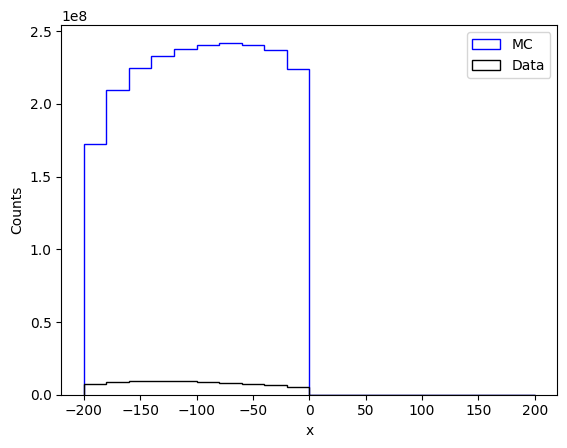

In [45]:
h_trk_mc_x_0 = F_mc_x["hTrack0_proj_axis0"]
h_trk_data_x_0 = F_data_x["hTrack0_proj_axis0"]

values, edges = h_trk_mc_x_0.to_numpy()

print(edges)

plt.hist(
    edges[:-1],
    bins=edges,
    weights=values,
    histtype="step",
    label="MC",
    color="blue",
)

values, edges = h_trk_data_x_0.to_numpy()   

plt.hist(
    edges[:-1], 
    bins=edges,
    weights=values,
    histtype="step",
    label="Data",
    color="black",
)


plt.xlabel("x")
plt.ylabel("Counts")
plt.legend()

plt.show()

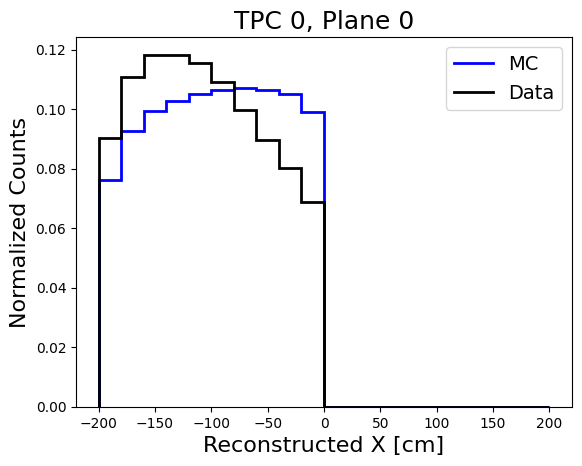

In [ ]:
def plot_1d(idx, ax):
    axes = {"x":0, "y":1, "z":2}
    F_mc = uproot.open(files_mc_1d[ax])
    F_data = uproot.open(files_data_1d[ax])
    
    h_trk_mc = F_mc[f"hTrack{idx}_proj_axis{axes[ax]}"]
    h_trk_data = F_data[f"hTrack{idx}_proj_axis{axes[ax]}"]

    values, edges = h_trk_mc.to_numpy()
    norm_values = values / np.sum(values)
    plt.stairs(norm_values, edges, label="MC", color="blue", linewidth=2)

    values, edges = h_trk_data.to_numpy()   
    norm_values = values / np.sum(values)
    plt.stairs(norm_values, edges, label="Data", color="black", linewidth=2)




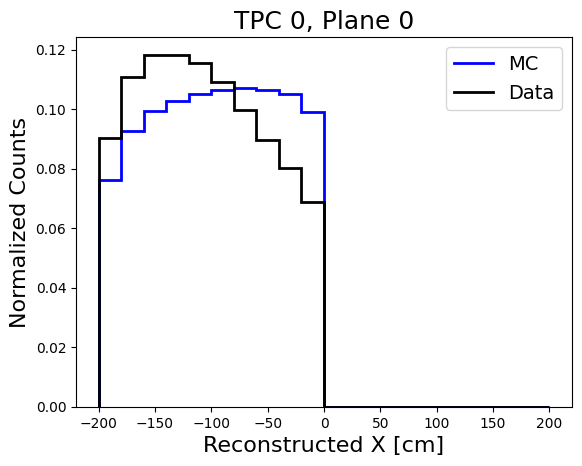

In [61]:
TPC = 0
PLANE = 0
IDX = 3*TPC + PLANE

plot_1d(IDX, "x")
plt.xlabel("Reconstructed X [cm]", fontsize=16)
plt.ylabel("Normalized Counts", fontsize=16)
plt.legend(fontsize=14)
plt.title(f"TPC {TPC}, Plane {PLANE}", fontsize=18)
plt.show()

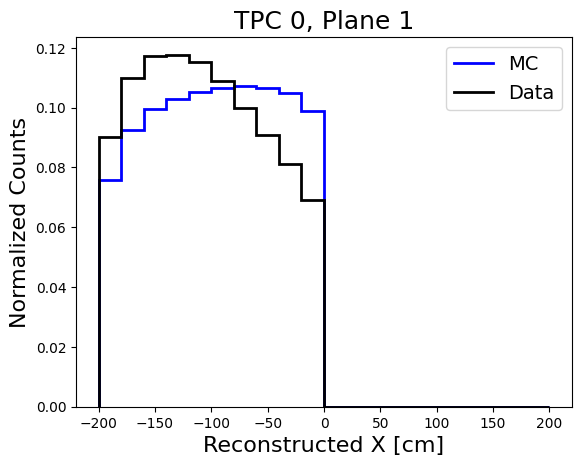

In [48]:
plot_1d(1, "x")
plt.xlabel("Reconstructed X [cm]", fontsize=16)
plt.ylabel("Normalized Counts", fontsize=16)
plt.legend(fontsize=14)
plt.title("TPC 0, Plane 1", fontsize=18)
plt.show()

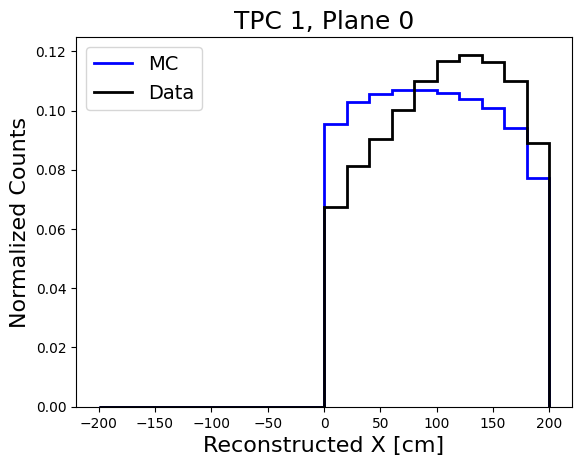

In [51]:
plot_1d(3, "x")
plt.xlabel("Reconstructed X [cm]", fontsize=16)
plt.ylabel("Normalized Counts", fontsize=16)
plt.legend(fontsize=14)
plt.title("TPC 1, Plane 0", fontsize=18)
plt.show()

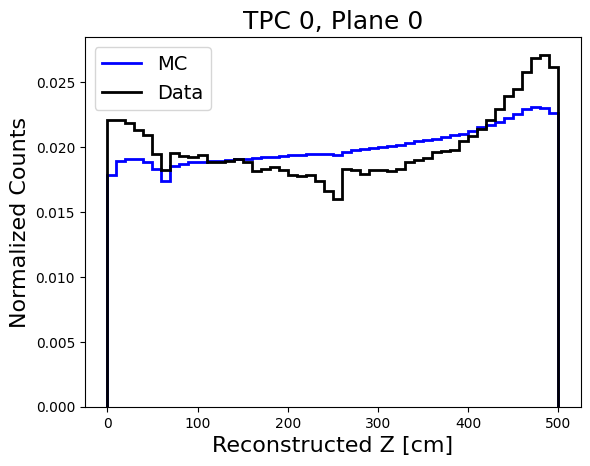

In [49]:
plot_1d(0, "z")
plt.xlabel("Reconstructed Z [cm]", fontsize=16)
plt.ylabel("Normalized Counts", fontsize=16)
plt.legend(fontsize=14)
plt.title("TPC 0, Plane 0", fontsize=18)
plt.show()

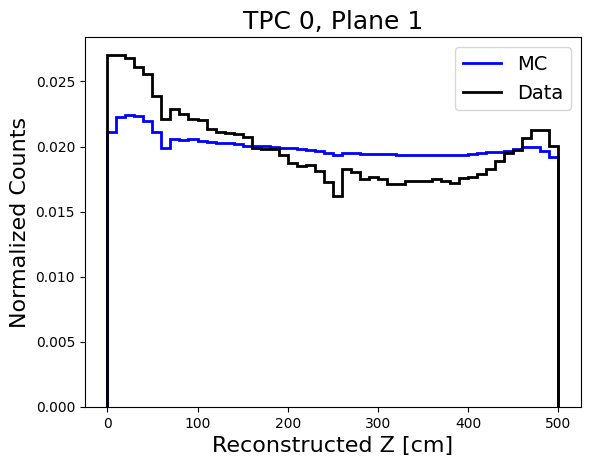

In [50]:
plot_1d(1, "z")
plt.xlabel("Reconstructed Z [cm]", fontsize=16)
plt.ylabel("Normalized Counts", fontsize=16)
plt.legend(fontsize=14)
plt.title("TPC 0, Plane 1", fontsize=18)
plt.show()

In [40]:
stop

NameError: name 'stop' is not defined

In [ ]:
DATA_Q_F = FILE_DIR+"WireMod_GEN2_V0_DATA_Proj_XYZ_Q_Full.root"
DATA_W_F = FILE_DIR+"WireMod_GEN2_V0_DATA_Proj_XYZ_W_Full.root"
MC_Q_F = FILE_DIR+"WireMod_GEN2_V0_MC_Proj_XYZ_Q_Full.root"
MC_W_F = FILE_DIR+"WireMod_GEN2_V0_MC_Proj_XYZ_W_Full.root"

AttributeError: 'Model_THnSparseT_3c_TArrayD_3e__v1' object has no attribute 'to_numpy'

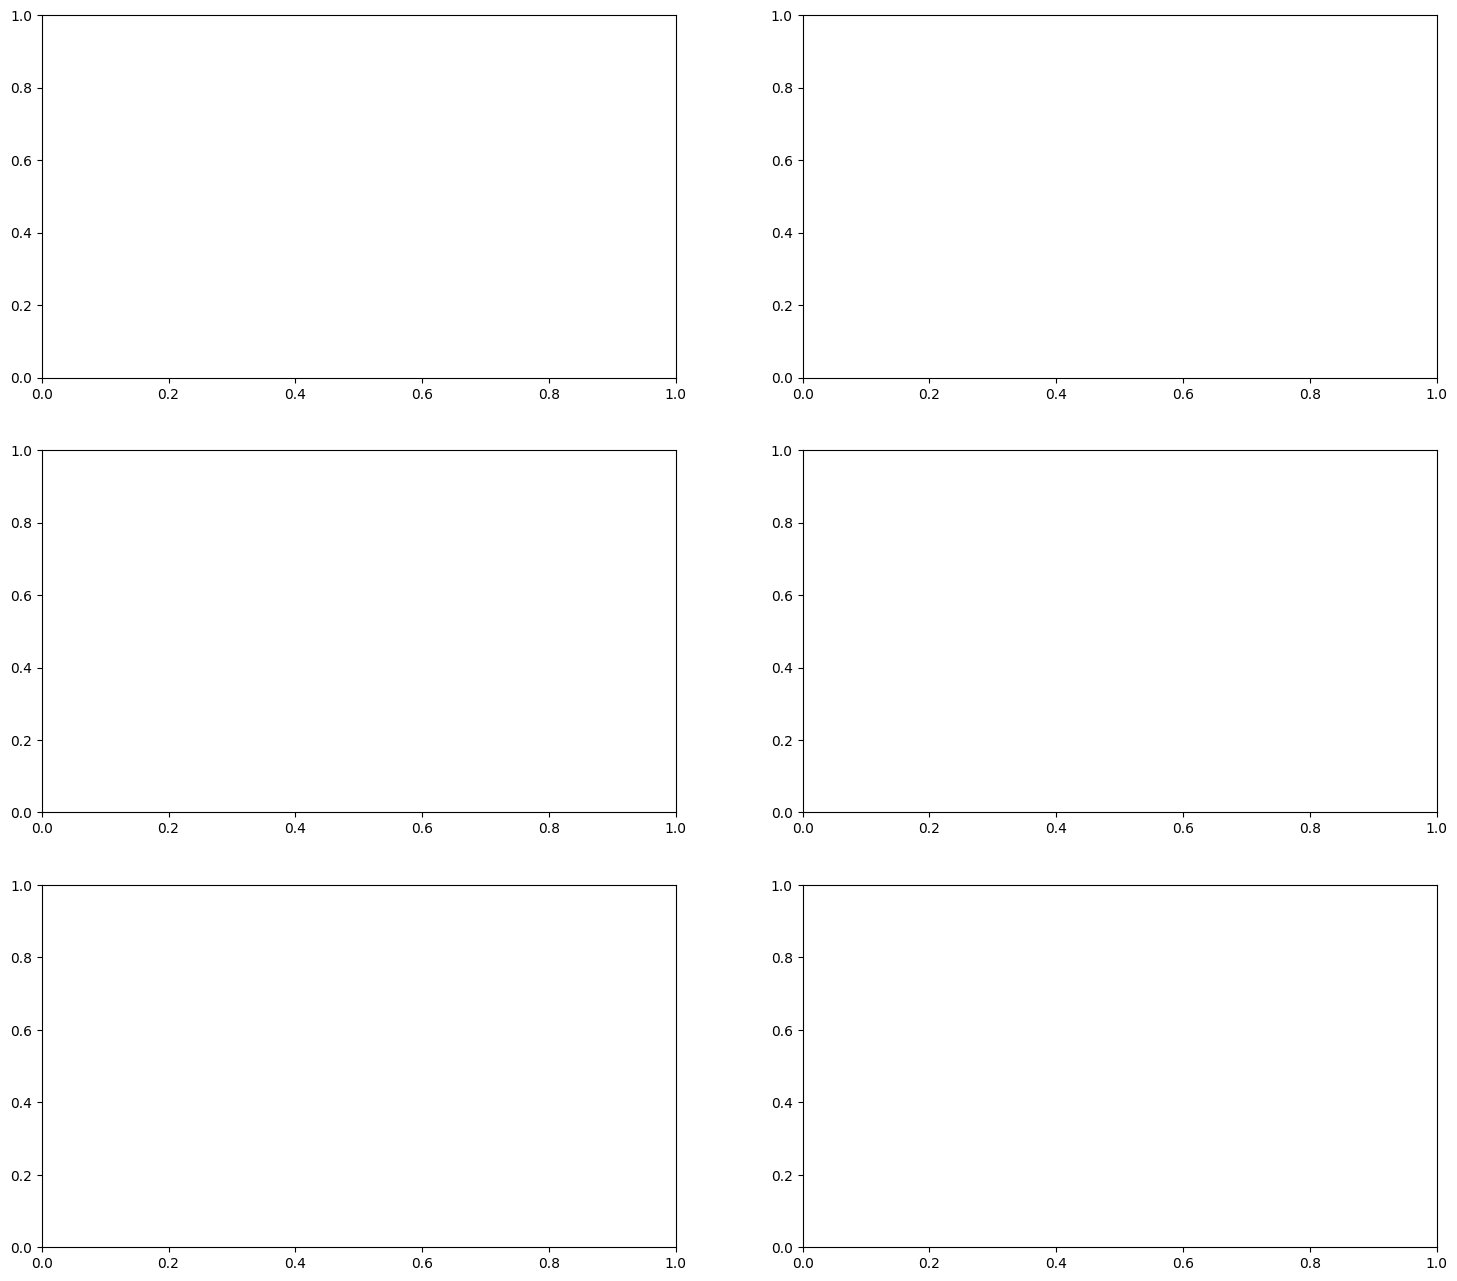

In [ ]:
# Plot Raw YZ binning for the charges

TPC = 0
fig, axes = plt.subplots(3, 2, figsize=(18, 16))
for plane in range(3):
    idx = 3*TPC + plane

    mc_f = uproot.open(MC_Q_F)
    data_f = uproot.open(DATA_Q_F)
    hmc = mc_f["hTrack"+str(idx)]
    hd = data_f["hTrack"+str(idx)]

    z_values, x_edges, y_edges = hmc.to_numpy()
 
    #z_values = z_values.T

    # MC First
    z_masked = np.ma.masked_where(z_values == 0, z_values)
    cmap = plt.cm.viridis.copy()
    cmap.set_bad(color='white')

    #X, Y = np.meshgrid(x_edges, y_edges, indexing='ij') 
    X, Y = np.meshgrid(y_edges, x_edges)
    
    pcm = axes[plane][0].pcolormesh(X, Y, z_masked, cmap=cmap, rasterized=True, shading='auto')

    fig.colorbar(pcm, ax=axes[plane][0]) 
    axes[plane][0].set_title(f"MC (Gen2): TPC {TPC}, Plane {plane}")     
    #hmc.Delete()

    # Data Second

    #z_values, x_edges, y_edges = hd.to_numpy()
    z_values, x_edges, y_edges = hd.to_numpy()

    #x_edges, y_edges, z_values = root_th2d_to_plt_hist2d(hd)
    z_masked = np.ma.masked_where(z_values == 0, z_values)
    cmap = plt.cm.viridis.copy()
    cmap.set_bad(color='white')

    X, Y = np.meshgrid(y_edges, x_edges)  # Needed for pcolormesh
    #pcm = axs.pcolormesh(X, Y, z_masked, cmap=cmap, shading='auto', vmin=zlim[0], vmax=zlim[1])
    pcm = axes[plane][1].pcolormesh(X, Y, z_masked, cmap=cmap, rasterized=True, shading='auto')

    fig.colorbar(pcm, ax=axes[plane][1]) 
    axes[plane][1].set_title(f"Data (Gen2): TPC {TPC}, Plane {plane}")     
    #hd.Delete()

fig.supxlabel("Reconstructed Z [cm]", fontsize=30)
fig.supylabel('Reconstructed Y [cm]', fontsize=30)
plt.tight_layout()
#plt.savefig(Figure_Dir + f"tracks_yz_east_tpc{TPC}_plane{plane}.png", bbox_inches="tight")
plt.show()
